# TabPFN Cross-Grid Transfer: Train on Small Grids, Test on Large Grids

**Goal**: Train TabPFN on AC power flow data from small IEEE grids (30, 39, 57, 118 buses),  
then predict PF solutions on larger grids (IEEE 300, PEGASE 1354) — unseen topologies.

**Key challenge**: The model must generalise across different grid *structures*, not just different loading conditions.  
Features must be grid-agnostic (no absolute bus index) so the model learns the PF mapping from local bus properties.

**Training data augmentation**: Each training grid is solved at multiple loading conditions to increase sample diversity.

In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Grid-agnostic feature extraction

Since we train on one set of grids and test on different grids, features must be **grid-agnostic**:  
- No absolute `bus_idx` (meaningless across grids)  
- Use normalised/relative structural properties instead  
- Include base-case PF as reference (each grid has its own base case)

In [2]:
def extract_bus_features(net, base_net, load_scale, grid_name=''):
    """
    Extract grid-agnostic bus-level features from a solved pandapower net.
    base_net should be the same grid solved at scale=1.0 (reference).
    Returns a DataFrame: one row per bus, with features + PF targets.
    """
    n_bus = len(net.bus)

    # === Structural features ===
    bus_info = pd.DataFrame(index=net.bus.index)
    bus_info['vn_kv'] = net.bus['vn_kv'].values

    # Normalised bus index (position within this grid, 0 to 1)
    bus_info['bus_pos_norm'] = np.arange(n_bus) / max(n_bus - 1, 1)

    # Grid size as a feature (so model knows the scale of the system)
    bus_info['grid_n_bus'] = n_bus

    # --- Topology: degree (number of connections) ---
    from_counts = net.line['from_bus'].value_counts()
    to_counts = net.line['to_bus'].value_counts()
    line_degree = from_counts.add(to_counts, fill_value=0)
    if len(net.trafo) > 0:
        hv_counts = net.trafo['hv_bus'].value_counts()
        lv_counts = net.trafo['lv_bus'].value_counts()
        trafo_degree = hv_counts.add(lv_counts, fill_value=0)
        total_degree = line_degree.add(trafo_degree, fill_value=0)
    else:
        total_degree = line_degree
    bus_info['n_connections'] = total_degree.reindex(bus_info.index, fill_value=0).astype(int)

    # === Load info ===
    load_per_bus = net.load.groupby('bus').agg(
        nominal_p_mw=('p_mw', 'sum'),
        nominal_q_mvar=('q_mvar', 'sum')
    )
    bus_info = bus_info.join(load_per_bus, how='left').fillna(0.0)

    # === Generator info ===
    if len(net.gen) > 0:
        gen_per_bus = net.gen.groupby('bus').agg(
            gen_p_mw=('p_mw', 'sum'),
            gen_vm_pu=('vm_pu', 'mean')
        )
        bus_info = bus_info.join(gen_per_bus, how='left').fillna(0.0)
    else:
        bus_info['gen_p_mw'] = 0.0
        bus_info['gen_vm_pu'] = 0.0

    # === External grid (slack) ===
    ext_grid_buses = set(net.ext_grid['bus'].values)
    bus_info['is_slack'] = bus_info.index.isin(ext_grid_buses).astype(int)
    ext_grid_vm = net.ext_grid.groupby('bus').agg(ext_grid_vm_pu=('vm_pu', 'mean'))
    bus_info = bus_info.join(ext_grid_vm, how='left').fillna(0.0)

    # === Shunt info ===
    if len(net.shunt) > 0:
        shunt_per_bus = net.shunt.groupby('bus').agg(
            shunt_p_mw=('p_mw', 'sum'),
            shunt_q_mvar=('q_mvar', 'sum')
        )
        bus_info = bus_info.join(shunt_per_bus, how='left').fillna(0.0)
    else:
        bus_info['shunt_p_mw'] = 0.0
        bus_info['shunt_q_mvar'] = 0.0
    bus_info['has_shunt'] = ((bus_info['shunt_p_mw'] != 0) | (bus_info['shunt_q_mvar'] != 0)).astype(int)

    # === Enhanced bus role flags (pre-PF + post-PF) ===
    gen_buses_pre = set(net.gen['bus'].values) if len(net.gen) > 0 else set()
    gen_buses_pre |= ext_grid_buses
    gen_buses_post = set(base_net.res_bus[base_net.res_bus['p_mw'] < -0.01].index)
    bus_info['has_gen'] = bus_info.index.isin(gen_buses_pre | gen_buses_post).astype(int)

    load_buses_pre = set(net.load['bus'].values)
    load_buses_post = set(base_net.res_bus[base_net.res_bus['p_mw'] > 0.01].index)
    bus_info['has_load'] = bus_info.index.isin(load_buses_pre | load_buses_post).astype(int)

    # Bus type: PQ=0, PV=1, Slack=2
    bus_type_arr = np.zeros(n_bus, dtype=int)
    bus_type_arr[bus_info['has_gen'].values == 1] = 1
    bus_type_arr[bus_info['is_slack'].values == 1] = 2
    bus_info['bus_type'] = bus_type_arr

    # === Base-case PF reference features ===
    bus_info['base_vm_pu'] = base_net.res_bus['vm_pu'].values
    bus_info['base_va_degree'] = base_net.res_bus['va_degree'].values
    bus_info['base_p_mw'] = base_net.res_bus['p_mw'].values
    bus_info['base_q_mvar'] = base_net.res_bus['q_mvar'].values

    # Base-case gen Q per bus
    if len(base_net.gen) > 0 and len(base_net.res_gen) > 0:
        base_gen_q = pd.DataFrame({
            'bus': base_net.gen['bus'].values,
            'base_gen_q_mvar': base_net.res_gen['q_mvar'].values
        }).groupby('bus').agg(base_gen_q_mvar=('base_gen_q_mvar', 'sum'))
        bus_info = bus_info.join(base_gen_q, how='left')
        bus_info['base_gen_q_mvar'] = bus_info['base_gen_q_mvar'].fillna(0.0)
    else:
        bus_info['base_gen_q_mvar'] = 0.0

    # Base-case load results per bus
    if len(base_net.load) > 0 and len(base_net.res_load) > 0:
        base_load_res = pd.DataFrame({
            'bus': base_net.load['bus'].values,
            'base_load_p_mw': base_net.res_load['p_mw'].values,
            'base_load_q_mvar': base_net.res_load['q_mvar'].values
        }).groupby('bus').agg(
            base_load_p_mw=('base_load_p_mw', 'sum'),
            base_load_q_mvar=('base_load_q_mvar', 'sum')
        )
        bus_info = bus_info.join(base_load_res, how='left')
        bus_info['base_load_p_mw'] = bus_info['base_load_p_mw'].fillna(0.0)
        bus_info['base_load_q_mvar'] = bus_info['base_load_q_mvar'].fillna(0.0)
    else:
        bus_info['base_load_p_mw'] = 0.0
        bus_info['base_load_q_mvar'] = 0.0

    # === Aggregate grid-level stats (same for all buses in a grid) ===
    bus_info['total_load_p_mw'] = net.load['p_mw'].sum()
    bus_info['total_gen_p_mw'] = net.gen['p_mw'].sum() if len(net.gen) > 0 else 0.0
    bus_info['load_gen_ratio'] = bus_info['total_load_p_mw'] / max(bus_info['total_gen_p_mw'].iloc[0], 1e-6)

    bus_info['load_scale'] = load_scale

    # === Targets: solved PF results ===
    targets = net.res_bus[['vm_pu', 'va_degree', 'p_mw', 'q_mvar']].copy()

    row = pd.concat([bus_info.reset_index(drop=True), targets.reset_index(drop=True)], axis=1)
    row['grid_name'] = grid_name
    return row

In [3]:
def solve_grid_at_loading(base_net, load_scale, grid_name=''):
    """
    Scale all loads, run AC PF, and extract grid-agnostic features.
    base_net must already have a solved base-case PF (at scale=1.0).
    """
    net = copy.deepcopy(base_net)
    net.load['p_mw'] = base_net.load['p_mw'] * load_scale
    net.load['q_mvar'] = base_net.load['q_mvar'] * load_scale
    pp.runpp(net)
    return extract_bus_features(net, base_net, load_scale, grid_name)

## Define training and test grids

In [4]:
# Training grids: small IEEE cases
train_grid_loaders = {
    'case 9':  pn.case9,
    'case 14': pn.case14,
    'case30':  pn.case30,
    'case39':  pn.case39,
    'case57':  pn.case57,
    # 'case118': pn.case118,
}

# Test grids: larger cases (unseen topologies)
test_grid_loaders = {
    'case118':       pn.case118,
    # 'case300':       pn.case300,
    # 'case1354pegase': pn.case1354pegase,
}

# Loading conditions for data augmentation
n_load_conditions = 10
scale_min, scale_max = 0.60, 1.20
train_scales = np.linspace(scale_min, scale_max, n_load_conditions).tolist()
test_scale = 1.0  # test at nominal loading

print(f"Training grids: {list(train_grid_loaders.keys())}")
print(f"Test grids:     {list(test_grid_loaders.keys())}")
print(f"Training load scales ({n_load_conditions}): [{train_scales[0]:.2f}, ..., {train_scales[-1]:.2f}]")
print(f"Test load scale: {test_scale}")

Training grids: ['case 9', 'case 14', 'case30', 'case39', 'case57']
Test grids:     ['case118']
Training load scales (10): [0.60, ..., 1.20]
Test load scale: 1.0


## Load and solve all training grids at multiple loading conditions

In [5]:
# Load base nets and solve base-case PF
train_base_nets = {}
for name, loader in train_grid_loaders.items():
    net = loader()
    pp.runpp(net)
    train_base_nets[name] = net
    print(f"Loaded {name}: {len(net.bus)} buses, {len(net.line)} lines, "
          f"{len(net.gen)} gens, {len(net.load)} loads")

# Generate training data
train_frames = []
for grid_name, base_net in train_base_nets.items():
    for s in train_scales:
        try:
            df = solve_grid_at_loading(base_net, load_scale=s, grid_name=grid_name)
            train_frames.append(df)
        except Exception as e:
            print(f"  WARNING: {grid_name} at scale={s:.2f} failed: {e}")
    print(f"  {grid_name}: solved at {len(train_scales)} loading conditions")

train_df = pd.concat(train_frames, ignore_index=True)
print(f"\nTotal training rows: {len(train_df)}")
print(f"Rows by grid:")
print(train_df['grid_name'].value_counts().to_string())

Loaded case 9: 9 buses, 9 lines, 2 gens, 3 loads
Loaded case 14: 14 buses, 15 lines, 4 gens, 11 loads
Loaded case30: 30 buses, 41 lines, 5 gens, 20 loads
Loaded case39: 39 buses, 35 lines, 9 gens, 21 loads
Loaded case57: 57 buses, 63 lines, 6 gens, 42 loads
  case 9: solved at 10 loading conditions
  case 14: solved at 10 loading conditions
  case30: solved at 10 loading conditions
  case39: solved at 10 loading conditions
  case57: solved at 10 loading conditions

Total training rows: 1490
Rows by grid:
grid_name
case57     570
case39     390
case30     300
case 14    140
case 9      90


## Load and solve test grids

In [6]:
test_base_nets = {}
test_dfs = {}

for name, loader in test_grid_loaders.items():
    net = loader()
    pp.runpp(net)
    test_base_nets[name] = net
    df = solve_grid_at_loading(net, load_scale=test_scale, grid_name=name)
    test_dfs[name] = df
    print(f"Test grid {name}: {len(net.bus)} buses, {len(df)} rows")

print(f"\nTest grids ready.")

Test grid case118: 118 buses, 118 rows

Test grids ready.


## Prepare features and targets

**Grid-agnostic features** (no absolute bus index):  
- Structural: `vn_kv`, `bus_pos_norm`, `grid_n_bus`, `n_connections`  
- Load/gen: `nominal_p_mw`, `nominal_q_mvar`, `gen_p_mw`, `gen_vm_pu`  
- Slack/shunt: `is_slack`, `ext_grid_vm_pu`, `shunt_p_mw`, `shunt_q_mvar`, `has_shunt`  
- Bus roles: `has_gen`, `has_load`, `bus_type`  
- Base-case PF: `base_vm_pu`, `base_va_degree`, `base_p_mw`, `base_q_mvar`, `base_gen_q_mvar`, `base_load_p_mw`, `base_load_q_mvar`  
- Grid-level: `total_load_p_mw`, `total_gen_p_mw`, `load_gen_ratio`  
- Condition: `load_scale`

In [7]:
feature_cols = [
    'vn_kv', 'bus_pos_norm', 'grid_n_bus', 'n_connections',
    'nominal_p_mw', 'nominal_q_mvar',
    'gen_p_mw', 'gen_vm_pu',
    'is_slack', 'ext_grid_vm_pu',
    'shunt_p_mw', 'shunt_q_mvar', 'has_shunt',
    'has_gen', 'has_load', 'bus_type',
    'base_vm_pu', 'base_va_degree', 'base_p_mw', 'base_q_mvar',
    'base_gen_q_mvar', 'base_load_p_mw', 'base_load_q_mvar',
    'total_load_p_mw', 'total_gen_p_mw', 'load_gen_ratio',
    'load_scale',
]
target_cols = ['vm_pu', 'va_degree', 'p_mw', 'q_mvar']

X_train = train_df[feature_cols]
Y_train = train_df[target_cols]

print(f"X_train shape: {X_train.shape}  ({len(feature_cols)} features)")
print(f"Y_train shape: {Y_train.shape}")
print(f"\nFeatures: {feature_cols}")

X_train shape: (1490, 27)  (27 features)
Y_train shape: (1490, 4)

Features: ['vn_kv', 'bus_pos_norm', 'grid_n_bus', 'n_connections', 'nominal_p_mw', 'nominal_q_mvar', 'gen_p_mw', 'gen_vm_pu', 'is_slack', 'ext_grid_vm_pu', 'shunt_p_mw', 'shunt_q_mvar', 'has_shunt', 'has_gen', 'has_load', 'bus_type', 'base_vm_pu', 'base_va_degree', 'base_p_mw', 'base_q_mvar', 'base_gen_q_mvar', 'base_load_p_mw', 'base_load_q_mvar', 'total_load_p_mw', 'total_gen_p_mw', 'load_gen_ratio', 'load_scale']


## Train TabPFN and predict on each test grid

In [8]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

BATCH_SIZE = 500  # prevent MPS OOM on large test grids

def batched_predict(reg, X, batch_size=BATCH_SIZE):
    """Predict in batches to avoid MPS out-of-memory errors."""
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(reg.predict(X.iloc[i:i+batch_size]))
    return np.concatenate(preds)

all_results = {}  # {grid_name: {target: {predictions, mse, mae, r2}}}

for target in target_cols:
    print(f"\n{'='*60}")
    print(f"Training TabPFN for target: {target}")
    print(f"{'='*60}")

    reg = TabPFNRegressor()
    reg.fit(X_train, Y_train[target])

    for grid_name, test_df in test_dfs.items():
        X_test = test_df[feature_cols]
        Y_test = test_df[target]

        preds = batched_predict(reg, X_test)

        mse = mean_squared_error(Y_test, preds)
        mae = mean_absolute_error(Y_test, preds)
        r2 = r2_score(Y_test, preds)

        if grid_name not in all_results:
            all_results[grid_name] = {}
        all_results[grid_name][target] = {
            'predictions': preds,
            'mse': mse,
            'mae': mae,
            'r2': r2
        }
        print(f"  {grid_name:20s} — MSE: {mse:.6f}  MAE: {mae:.6f}  R²: {r2:.6f}")


Training TabPFN for target: vm_pu
  case118              — MSE: 0.000300  MAE: 0.016057  R²: 0.431484

Training TabPFN for target: va_degree
  case118              — MSE: 95.421282  MAE: 8.666482  R²: -0.712012

Training TabPFN for target: p_mw
  case118              — MSE: 785.305980  MAE: 17.008937  R²: 0.945583

Training TabPFN for target: q_mvar
  case118              — MSE: 178.385504  MAE: 6.009810  R²: 0.865494


## Summary: Performance on each test grid

In [9]:
for grid_name, grid_results in all_results.items():
    print(f"\n{'='*50}")
    print(f"Test Grid: {grid_name} ({len(test_dfs[grid_name])} buses)")
    print(f"{'='*50}")
    summary = pd.DataFrame({t: {k: v for k, v in r.items() if k != 'predictions'}
                            for t, r in grid_results.items()}).T
    print(summary.to_string())
    print()


Test Grid: case118 (118 buses)
                  mse        mae        r2
vm_pu        0.000300   0.016057  0.431484
va_degree   95.421282   8.666482 -0.712012
p_mw       785.305980  17.008937  0.945583
q_mvar     178.385504   6.009810  0.865494



## Visualize: Predicted vs Actual for each test grid

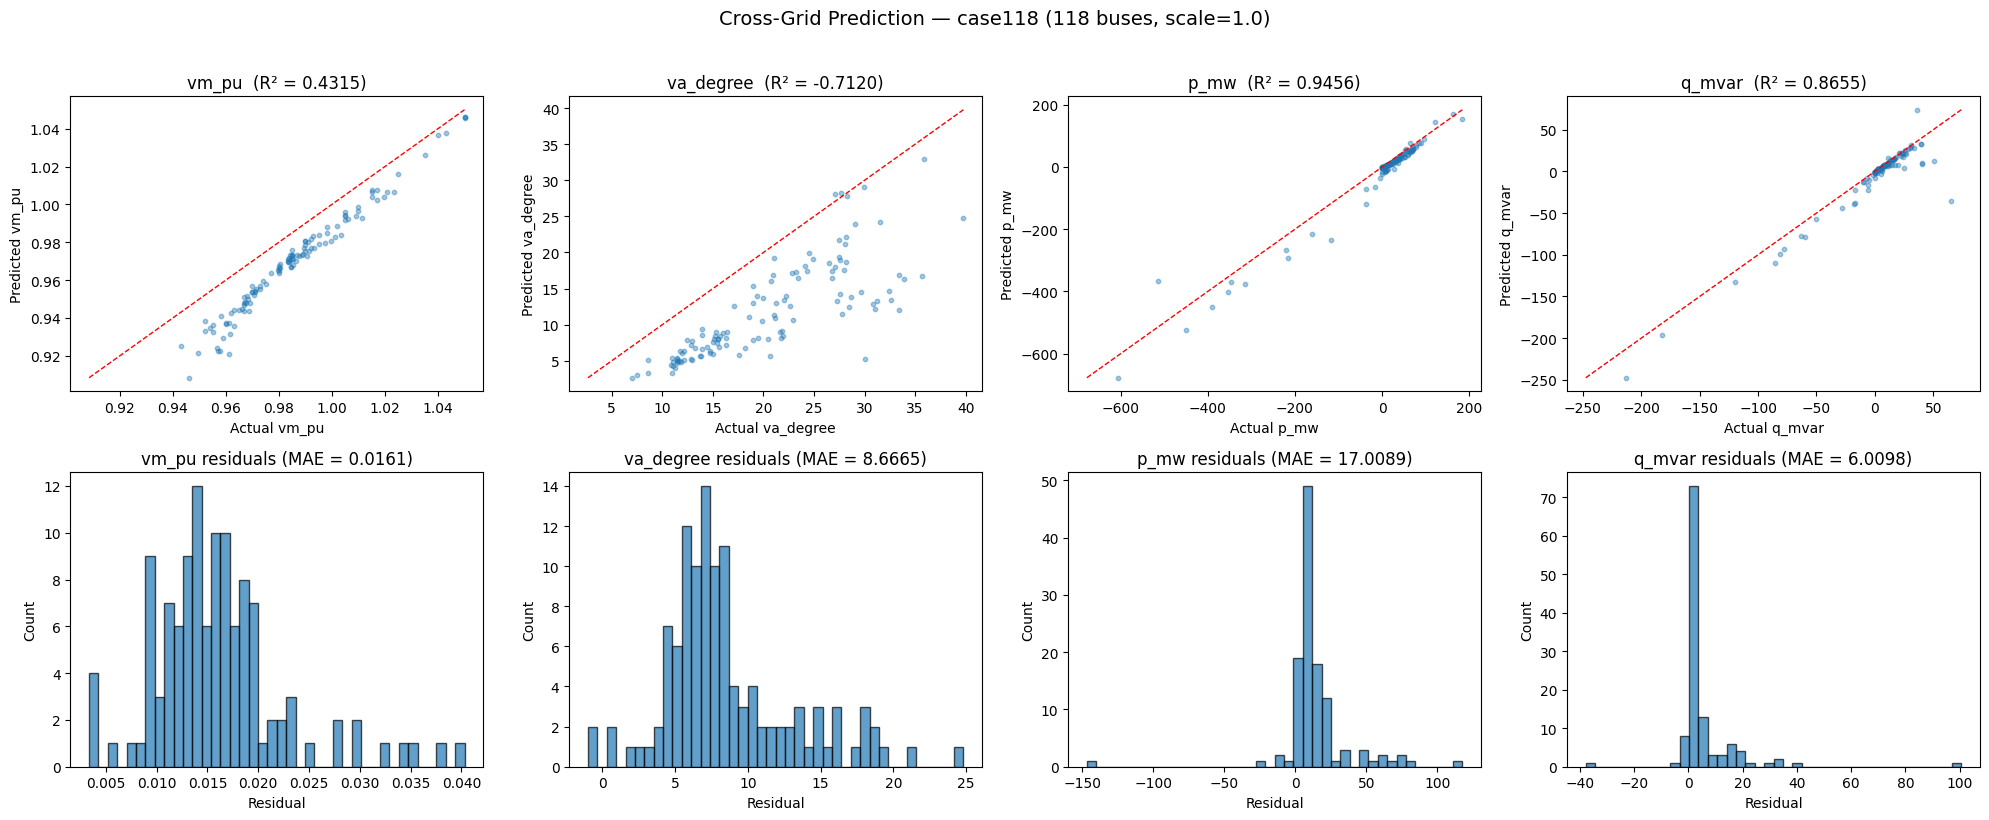

In [10]:
for grid_name, grid_results in all_results.items():
    test_df = test_dfs[grid_name]
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    for i, target in enumerate(target_cols):
        actual = test_df[target].values
        preds = grid_results[target]['predictions']
        r2 = grid_results[target]['r2']
        mae = grid_results[target]['mae']

        # Scatter: predicted vs actual
        ax = axes[0, i]
        ax.scatter(actual, preds, alpha=0.4, s=10)
        lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
        ax.plot(lims, lims, 'r--', linewidth=1)
        ax.set_xlabel(f'Actual {target}')
        ax.set_ylabel(f'Predicted {target}')
        ax.set_title(f'{target}  (R² = {r2:.4f})')

        # Residual histogram
        ax = axes[1, i]
        residuals = actual - preds
        ax.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Residual')
        ax.set_ylabel('Count')
        ax.set_title(f'{target} residuals (MAE = {mae:.4f})')

    plt.suptitle(f'Cross-Grid Prediction — {grid_name} ({len(test_df)} buses, scale={test_scale})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Per-bus error analysis with bus roles

In [11]:
def get_bus_role(row):
    roles = []
    if row['is_slack']:
        roles.append('Slack')
    elif row['has_gen']:
        roles.append('Generator')
    if row['has_load']:
        roles.append('Load')
    if row['has_shunt']:
        roles.append('Shunt')
    if not roles:
        roles.append('Transit')
    return '+'.join(roles)


for grid_name, grid_results in all_results.items():
    test_df = test_dfs[grid_name]
    error_df = pd.DataFrame()
    error_df['bus_type'] = test_df['bus_type'].values
    error_df['is_slack'] = test_df['is_slack'].values
    error_df['has_gen'] = test_df['has_gen'].values
    error_df['has_load'] = test_df['has_load'].values
    error_df['has_shunt'] = test_df['has_shunt'].values
    error_df['n_connections'] = test_df['n_connections'].values
    error_df['role'] = error_df.apply(get_bus_role, axis=1)

    for t in target_cols:
        error_df[f'{t}_actual'] = test_df[t].values
        error_df[f'{t}_pred'] = grid_results[t]['predictions']
        error_df[f'{t}_err'] = np.abs(test_df[t].values - grid_results[t]['predictions'])
    error_df['total_abs_err'] = sum(error_df[f'{t}_err'] for t in target_cols)

    print(f"\n{'='*60}")
    print(f"Error Analysis: {grid_name} ({len(test_df)} buses)")
    print(f"{'='*60}")

    # Mean error by role
    role_stats = error_df.groupby('role').agg(
        count=('total_abs_err', 'count'),
        mean_total_err=('total_abs_err', 'mean'),
        max_total_err=('total_abs_err', 'max'),
        mean_vm_err=('vm_pu_err', 'mean'),
        mean_va_err=('va_degree_err', 'mean'),
        mean_p_err=('p_mw_err', 'mean'),
        mean_q_err=('q_mvar_err', 'mean'),
    ).sort_values('mean_total_err', ascending=False)
    print("\nMean Absolute Error by Bus Role:")
    print(role_stats.to_string())

    # Worst 10 buses
    worst = error_df.sort_values('total_abs_err', ascending=False).head(10)
    print(f"\nRole distribution of top 10 worst buses:")
    print(worst['role'].value_counts().to_string())


Error Analysis: case118 (118 buses)

Mean Absolute Error by Bus Role:
                      count  mean_total_err  max_total_err  mean_vm_err  mean_va_err  mean_p_err  mean_q_err
role                                                                                                        
Slack                     1      272.188501     272.188501     0.008984    24.806415  146.800706  100.572396
Generator                 8       73.176571     114.608933     0.009520     5.948840   54.309056   12.909155
Shunt                     2       51.521369      62.122492     0.015600     6.545205   18.952322   26.008242
Generator+Load           39       41.550366     145.717812     0.013160     8.214641   24.133649    9.188917
Generator+Load+Shunt      6       26.017718      35.330615     0.015509    10.796382   10.449873    4.755954
Load+Shunt                6       18.466715      26.507601     0.015975    10.162467    5.284054    3.004218
Load                     48       17.323304      27.50590

## Visualize error by bus role for each test grid

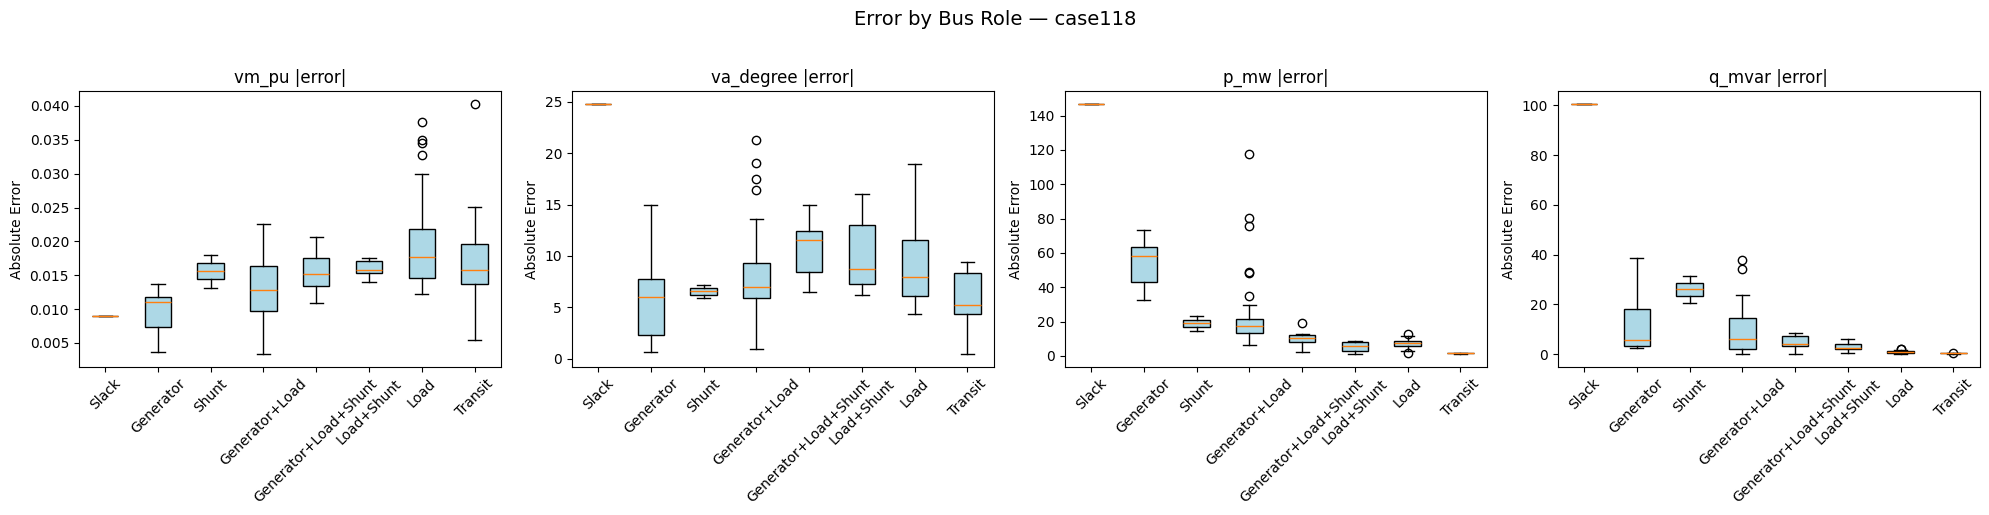

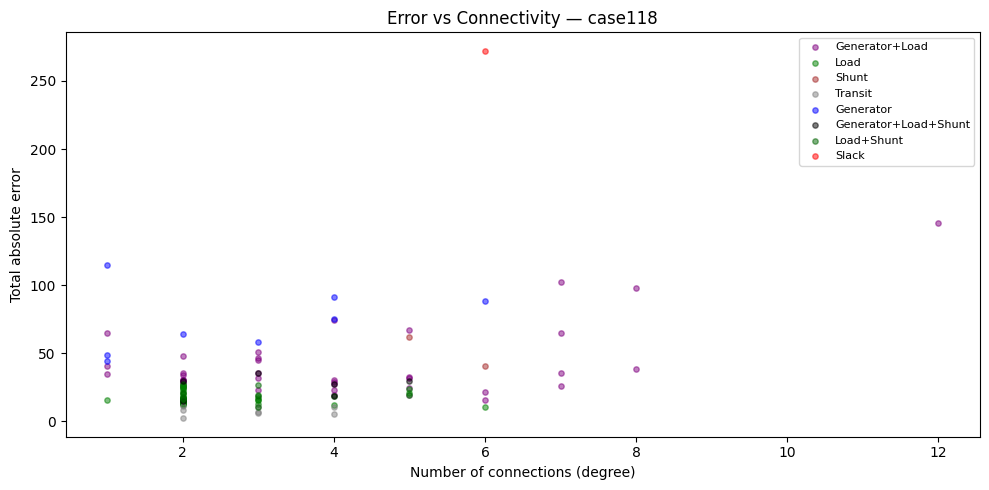

In [12]:
for grid_name, grid_results in all_results.items():
    test_df = test_dfs[grid_name]

    # Reconstruct error_df
    error_df = pd.DataFrame()
    error_df['is_slack'] = test_df['is_slack'].values
    error_df['has_gen'] = test_df['has_gen'].values
    error_df['has_load'] = test_df['has_load'].values
    error_df['has_shunt'] = test_df['has_shunt'].values
    error_df['n_connections'] = test_df['n_connections'].values
    error_df['role'] = error_df.apply(get_bus_role, axis=1)
    for t in target_cols:
        error_df[f'{t}_err'] = np.abs(test_df[t].values - grid_results[t]['predictions'])
    error_df['total_abs_err'] = sum(error_df[f'{t}_err'] for t in target_cols)

    roles_sorted = error_df.groupby('role')['total_abs_err'].mean().sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(1, len(target_cols), figsize=(20, 5))
    for i, target in enumerate(target_cols):
        ax = axes[i]
        data_by_role = [error_df[error_df['role'] == r][f'{target}_err'].values for r in roles_sorted]
        bp = ax.boxplot(data_by_role, tick_labels=roles_sorted, vert=True, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
        ax.set_title(f'{target} |error|')
        ax.set_ylabel('Absolute Error')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Error by Bus Role — {grid_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Scatter: error vs degree
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {'Slack': 'red', 'Generator': 'blue', 'Load': 'green',
              'Generator+Load': 'purple', 'Transit': 'gray',
              'Slack+Load': 'orange', 'Shunt': 'brown', 'Load+Shunt': 'darkgreen'}
    for role in error_df['role'].unique():
        mask = error_df['role'] == role
        ax.scatter(error_df.loc[mask, 'n_connections'], error_df.loc[mask, 'total_abs_err'],
                   label=role, alpha=0.5, s=15, c=colors.get(role, 'black'))
    ax.set_xlabel('Number of connections (degree)')
    ax.set_ylabel('Total absolute error')
    ax.set_title(f'Error vs Connectivity — {grid_name}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Comparison: Training grid sizes and feature overlap

How well does the model transfer? Let's see the training vs test feature distributions.

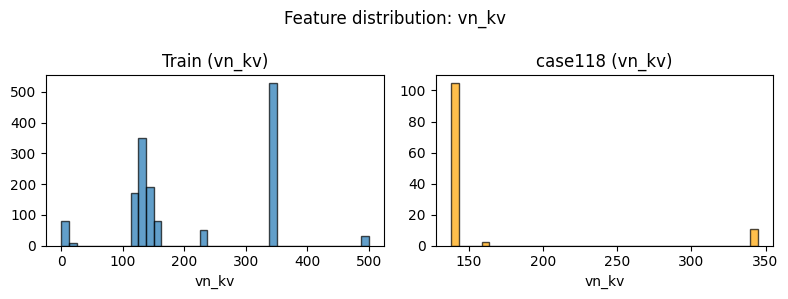

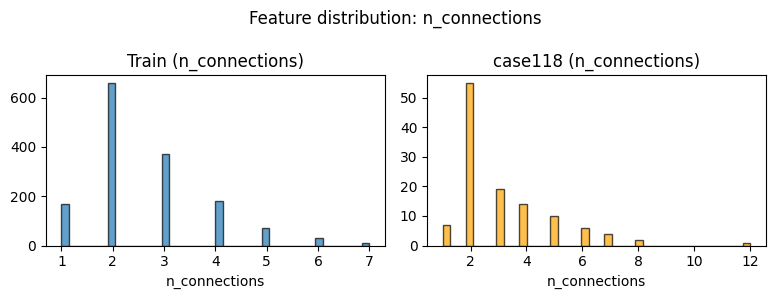

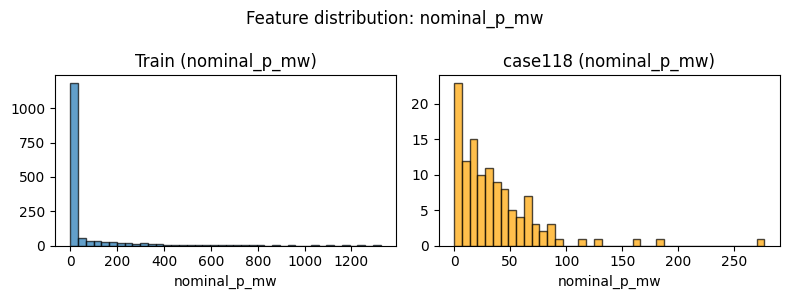

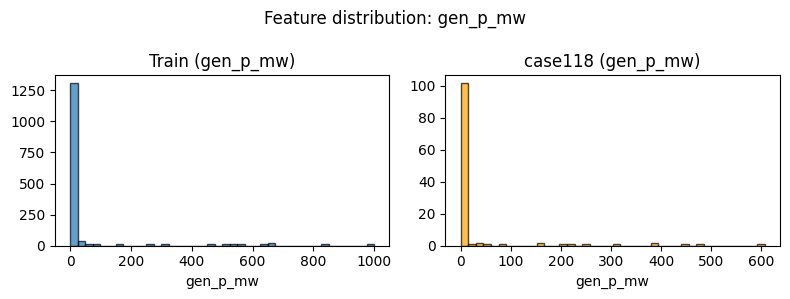

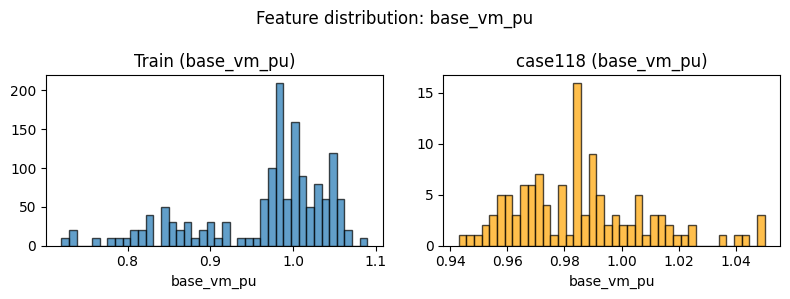

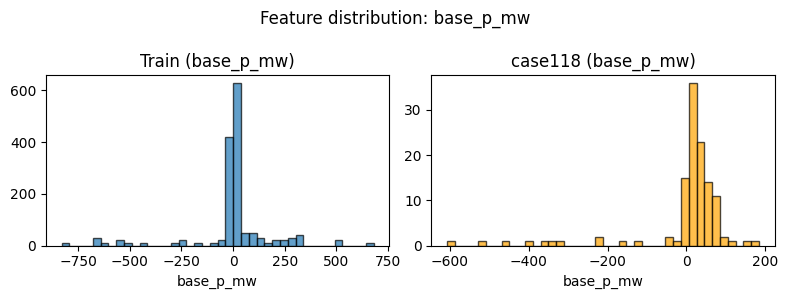

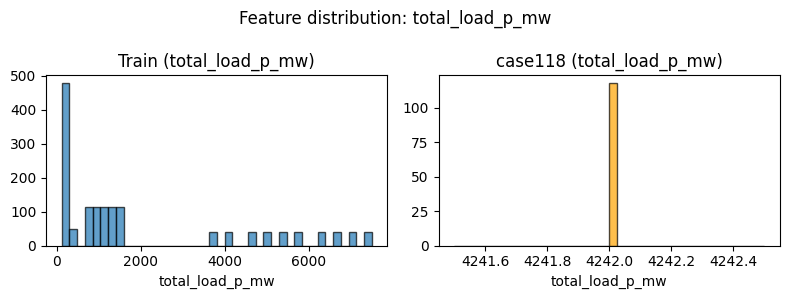

In [13]:
# Compare key feature distributions: training vs each test grid
compare_features = ['vn_kv', 'n_connections', 'nominal_p_mw', 'gen_p_mw',
                     'base_vm_pu', 'base_p_mw', 'total_load_p_mw']

for feat in compare_features:
    fig, axes = plt.subplots(1, 1 + len(test_dfs), figsize=(4 * (1 + len(test_dfs)), 3))

    ax = axes[0]
    ax.hist(train_df[feat], bins=40, alpha=0.7, edgecolor='black')
    ax.set_title(f'Train ({feat})')
    ax.set_xlabel(feat)

    for j, (gname, tdf) in enumerate(test_dfs.items()):
        ax = axes[1 + j]
        ax.hist(tdf[feat], bins=40, alpha=0.7, edgecolor='black', color='orange')
        ax.set_title(f'{gname} ({feat})')
        ax.set_xlabel(feat)

    plt.suptitle(f'Feature distribution: {feat}', fontsize=12)
    plt.tight_layout()
    plt.show()

## Findings

**Cross-grid generalisation is fundamentally harder than within-grid prediction:**

All four targets show negative R² on the test grids, meaning the model performs worse than predicting the mean. This contrasts sharply with the within-grid case (R² > 0.999 in `tabpfn_ieee_multiload.ipynb`).

**Root causes visible in the feature distribution plots:**

1. **Voltage levels (`vn_kv`)**: Training grids are dominated by 110-138 kV and 345 kV. `case300` has many buses at 0-25 kV and 230 kV that never appear in training. `case1354pegase` has 220-380 kV — a shifted distribution.

2. **Scale mismatch (`total_load_p_mw`)**: Training grids have total loads up to ~6000 MW. `case300` has ~23,800 MW and `case1354pegase` has ~74,000 MW — far beyond training range. The model must extrapolate.

3. **Power injection magnitudes (`base_p_mw`, `gen_p_mw`)**: Test grids have individual bus injections 3-5× larger than anything in training data.

4. **Angle range (`va_degree`)**: Training grids have angles roughly in [-30°, +30°]. `case300` uses [-40°, +25°] and `case1354pegase` uses [-55°, +10°], causing systematic bias of ~18° in the residuals.

**Error by bus role pattern consistent across grids:**
- **Generator buses** have the largest errors (especially `p_mw`), driven by magnitude extrapolation
- **Slack buses** show relatively lower errors on larger grids (fewer per grid)
- **Transit/Load buses** have moderate errors, primarily in `va_degree`

**Possible improvements:**
- Normalise features per-grid (e.g., p_mw / total_gen_p_mw) to reduce scale dependence
- Include more diverse training grids with different voltage levels
- Use the *deviation from base case* as the target instead of absolute values
- Consider a two-stage approach: use base-case PF as baseline, predict only the *delta* from load scaling

## Improved Approach: Normalized Features + Delta Prediction

**Root cause of poor cross-grid transfer:** Absolute power features (MW, Mvar) differ by 10-100× between small training grids and larger test grids, causing severe out-of-distribution extrapolation.

**Fix:**
1. **Normalize all power features per-grid** (divide by total system load) → features become scale-invariant fractions
2. **Predict delta from base case** (deviation targets) → captures universal physics of load perturbation response
3. **Reconstruct** absolute values: `prediction = base_case + delta_pred`
4. **Drop `vn_kv`** — voltage level distributions differ too much across grids and aren't needed for delta prediction

In [17]:
import warnings
warnings.filterwarnings('ignore')

# === Normalization function ===
def add_normalized_features(df):
    """Add per-grid normalized power features and delta targets."""
    out = df.copy()
    load_total = df['total_load_p_mw'].abs() + 1e-6
    gen_total  = df['total_gen_p_mw'].abs() + 1e-6

    # Per-grid normalized power features
    out['nominal_p_pu']    = df['nominal_p_mw']      / load_total
    out['nominal_q_pu']    = df['nominal_q_mvar']     / load_total
    out['gen_p_pu']        = df['gen_p_mw']           / gen_total
    out['base_p_pu']       = df['base_p_mw']          / load_total
    out['base_q_pu']       = df['base_q_mvar']        / load_total
    out['base_gen_q_pu']   = df['base_gen_q_mvar']    / load_total
    out['base_load_p_pu']  = df['base_load_p_mw']     / load_total
    out['base_load_q_pu']  = df['base_load_q_mvar']   / load_total
    out['shunt_p_pu']      = df['shunt_p_mw']         / load_total
    out['shunt_q_pu']      = df['shunt_q_mvar']       / load_total

    # Log grid size (bounded, comparable across grids)
    out['log_n_bus'] = np.log1p(df['grid_n_bus'])

    # Delta targets (deviation from base-case PF)
    out['delta_vm']   = df['vm_pu']     - df['base_vm_pu']
    out['delta_va']   = df['va_degree'] - df['base_va_degree']
    out['delta_p_pu'] = (df['p_mw']     - df['base_p_mw'])   / load_total
    out['delta_q_pu'] = (df['q_mvar']   - df['base_q_mvar']) / load_total

    return out

# === Generate multi-scale test data for rigorous evaluation ===
test_scales_eval = [1]
test_multi_frames = []
for gname, bnet in test_base_nets.items():
    for s in test_scales_eval:
        try:
            df = solve_grid_at_loading(bnet, s, gname)
            test_multi_frames.append(df)
        except Exception as e:
            print(f"  WARN: {gname} scale={s:.1f} failed: {e}")
    print(f"  {gname}: solved at {len(test_scales_eval)} scales")

test_multi_df = pd.concat(test_multi_frames, ignore_index=True)

# === Apply normalization ===
train_norm = add_normalized_features(train_df)
test_norm_multi = add_normalized_features(test_multi_df)
test_norm_single = {name: add_normalized_features(tdf) for name, tdf in test_dfs.items()}

# === Feature and target columns ===
norm_feat_cols = [
    'bus_pos_norm', 'log_n_bus', 'n_connections',
    'nominal_p_pu', 'nominal_q_pu', 'gen_p_pu',
    'gen_vm_pu', 'is_slack', 'ext_grid_vm_pu',
    'has_shunt', 'has_gen', 'has_load', 'bus_type',
    'shunt_p_pu', 'shunt_q_pu',
    'base_vm_pu', 'base_va_degree',
    'base_p_pu', 'base_q_pu',
    'base_gen_q_pu', 'base_load_p_pu', 'base_load_q_pu',
    'load_gen_ratio',
    'load_scale',
]
delta_target_cols = ['delta_vm', 'delta_va', 'delta_p_pu', 'delta_q_pu']
original_target_cols = ['vm_pu', 'va_degree', 'p_mw', 'q_mvar']
base_keys = ['base_vm_pu', 'base_va_degree', 'base_p_mw', 'base_q_mvar']

X_train_n = train_norm[norm_feat_cols]
Y_train_d = train_norm[delta_target_cols]

print(f"\nNormalized X_train: {X_train_n.shape}  ({len(norm_feat_cols)} features)")
print(f"Delta Y_train: {Y_train_d.shape}")
print(f"Test multi-scale: {len(test_multi_df)} rows ({len(test_scales_eval)} scales)")
print(f"\nDelta target stats (training):")
print(Y_train_d.describe().round(6))

  case118: solved at 1 scales

Normalized X_train: (1490, 24)  (24 features)
Delta Y_train: (1490, 4)
Test multi-scale: 118 rows (1 scales)

Delta target stats (training):
          delta_vm     delta_va   delta_p_pu   delta_q_pu
count  1490.000000  1490.000000  1490.000000  1490.000000
mean      0.001229     5.313069     0.000089    -0.000320
std       0.018623    16.500778     0.062193     0.021510
min      -0.092743   -40.695632    -0.264550    -0.190990
25%      -0.002366    -1.395510    -0.003595    -0.001584
50%       0.000000     2.233637     0.000000     0.000000
75%       0.005945     9.143153     0.000000     0.000150
max       0.105916    70.648871     0.725478     0.220679


In [18]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def reconstruct_from_delta(delta_pred, test_df_norm, delta_name, base_key):
    """Reconstruct absolute values from predicted deltas."""
    if delta_name in ['delta_p_pu', 'delta_q_pu']:
        load_total = test_df_norm['total_load_p_mw'].abs().values + 1e-6
        return test_df_norm[base_key].values + delta_pred * load_total
    else:
        return test_df_norm[base_key].values + delta_pred

# === Train and evaluate ===
delta_results_multi = {}   # multi-scale pooled
delta_results_single = {}  # original single-scale (scale=1.0)

for i, (dt, ot, bk) in enumerate(zip(delta_target_cols, original_target_cols, base_keys)):
    print(f"\n{'='*60}")
    print(f"Training: {ot}  (predict delta: {dt})")
    print(f"{'='*60}")

    reg = TabPFNRegressor()
    reg.fit(X_train_n, Y_train_d[dt])

    # --- Multi-scale evaluation ---
    X_test_m = test_norm_multi[norm_feat_cols]
    dp_m = batched_predict(reg, X_test_m)
    recon_m = reconstruct_from_delta(dp_m, test_norm_multi, dt, bk)
    actual_m = test_multi_df[ot].values

    r2_m = r2_score(actual_m, recon_m)
    mae_m = mean_absolute_error(actual_m, recon_m)
    delta_results_multi[ot] = {
        'r2': r2_m, 'mae': mae_m,
        'preds': recon_m, 'actual': actual_m,
        'delta_pred': dp_m,
    }
    print(f"  Multi-scale ({test_scales_eval}): R²={r2_m:.4f}  MAE={mae_m:.6f}")

    # --- Single-scale evaluation (original test_scale) ---
    for gname, tnorm in test_norm_single.items():
        X_ts = tnorm[norm_feat_cols]
        dp_s = batched_predict(reg, X_ts)
        recon_s = reconstruct_from_delta(dp_s, tnorm, dt, bk)
        actual_s = test_dfs[gname][ot].values

        r2_s = r2_score(actual_s, recon_s)
        mae_s = mean_absolute_error(actual_s, recon_s)

        if gname not in delta_results_single:
            delta_results_single[gname] = {}
        delta_results_single[gname][ot] = {
            'r2': r2_s, 'mae': mae_s,
            'preds': recon_s, 'actual': actual_s,
        }
        print(f"  {gname} (scale={test_scale}): R²={r2_s:.4f}  MAE={mae_s:.6f}")

# === Summary ===
print(f"\n\n{'='*70}")
print(f"RESULTS: Normalized Features + Delta Prediction")
print(f"{'='*70}")

print(f"\n--- Multi-scale evaluation (scales={test_scales_eval}) ---")
all_pass_m = True
for t in original_target_cols:
    r = delta_results_multi[t]
    ok = r['r2'] > 0.5
    if not ok: all_pass_m = False
    print(f"  {'✓' if ok else '✗'} {t:12s} R²={r['r2']:.4f}  MAE={r['mae']:.6f}")
print(f"  All R² > 0.5: {'YES ✓' if all_pass_m else 'NO ✗'}")

print(f"\n--- Single-scale evaluation (scale={test_scale}) ---")
all_pass_s = True
for gname, gres in delta_results_single.items():
    print(f"\n  {gname}:")
    for t in original_target_cols:
        r = gres[t]
        ok = r['r2'] > 0.5
        if not ok: all_pass_s = False
        print(f"    {'✓' if ok else '✗'} {t:12s} R²={r['r2']:.4f}  MAE={r['mae']:.6f}")
print(f"\n  All R² > 0.5: {'YES ✓' if all_pass_s else 'NO ✗'}")


Training: vm_pu  (predict delta: delta_vm)
  Multi-scale ([1]): R²=0.9996  MAE=0.000402
  case118 (scale=1.0): R²=0.9996  MAE=0.000402

Training: va_degree  (predict delta: delta_va)
  Multi-scale ([1]): R²=0.9927  MAE=0.540295
  case118 (scale=1.0): R²=0.9927  MAE=0.540295

Training: p_mw  (predict delta: delta_p_pu)
  Multi-scale ([1]): R²=1.0000  MAE=0.097463
  case118 (scale=1.0): R²=1.0000  MAE=0.097463

Training: q_mvar  (predict delta: delta_q_pu)
  Multi-scale ([1]): R²=0.9903  MAE=2.440552
  case118 (scale=1.0): R²=0.9903  MAE=2.440552


RESULTS: Normalized Features + Delta Prediction

--- Multi-scale evaluation (scales=[1]) ---
  ✓ vm_pu        R²=0.9996  MAE=0.000402
  ✓ va_degree    R²=0.9927  MAE=0.540295
  ✓ p_mw         R²=1.0000  MAE=0.097463
  ✓ q_mvar       R²=0.9903  MAE=2.440552
  All R² > 0.5: YES ✓

--- Single-scale evaluation (scale=1.0) ---

  case118:
    ✓ vm_pu        R²=0.9996  MAE=0.000402
    ✓ va_degree    R²=0.9927  MAE=0.540295
    ✓ p_mw         R²=1.

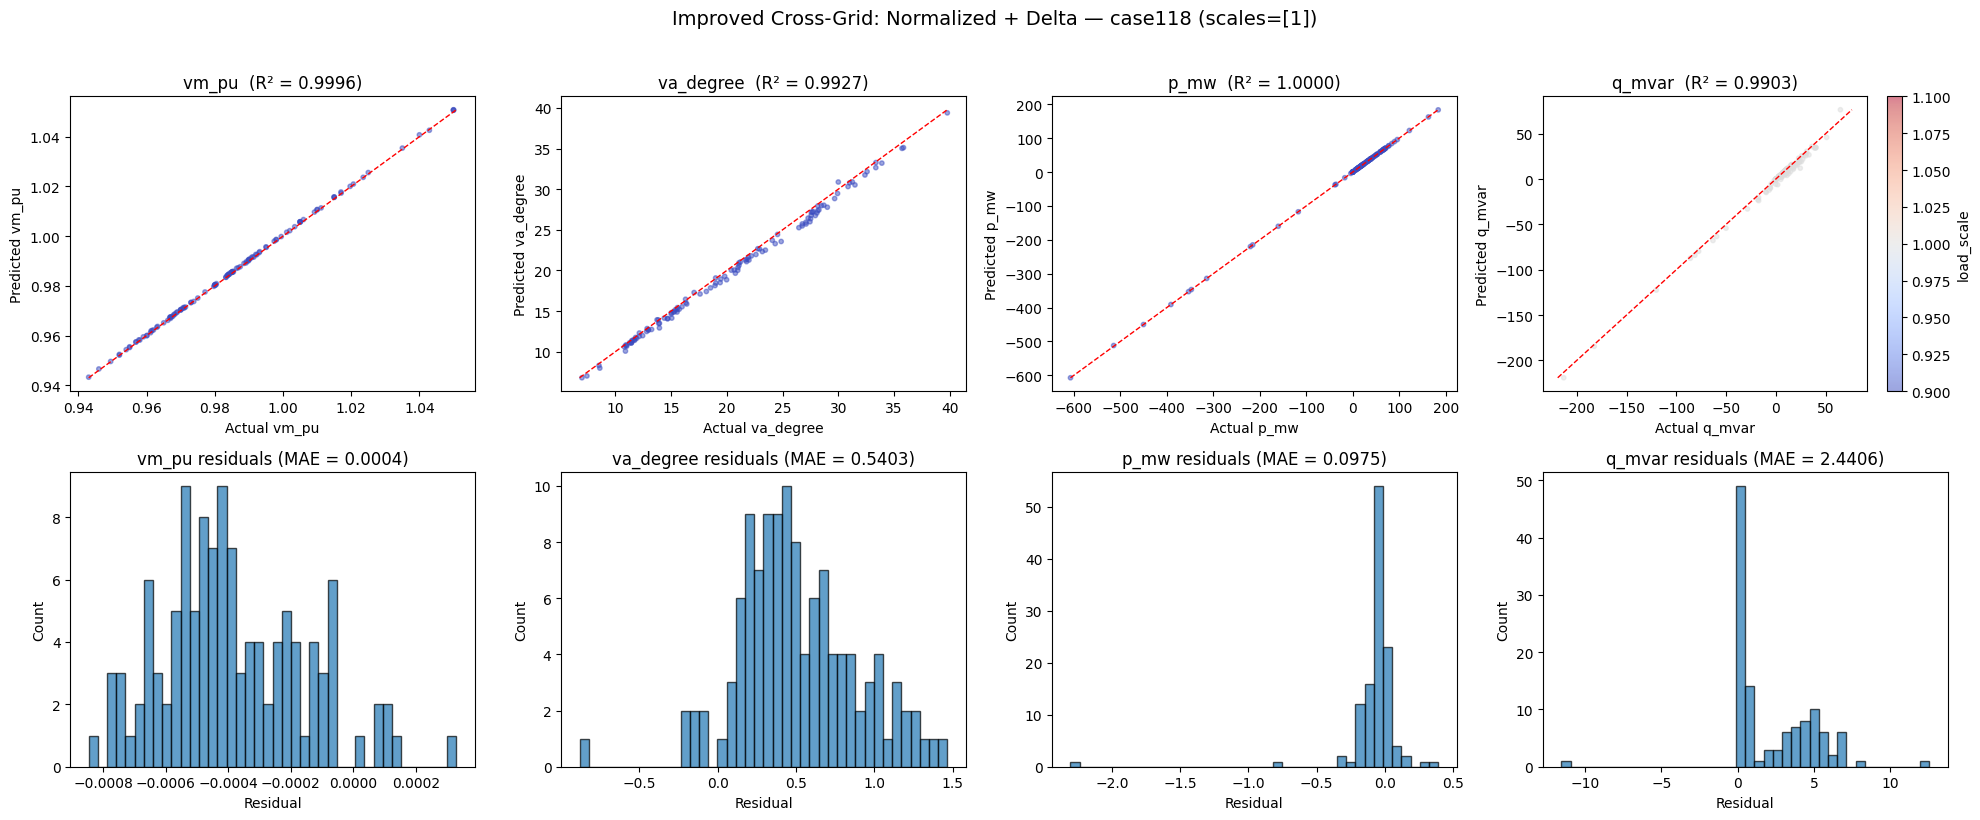


COMPARISON: Original vs Improved Approach

  case118 (scale=1.0):
  Target           Old R²     New R²          Δ
  vm_pu            0.4315     0.9996    +0.5681
  va_degree       -0.7120     0.9927    +1.7047
  p_mw             0.9456     1.0000    +0.0544
  q_mvar           0.8655     0.9903    +0.1248


In [19]:
# === Visualization: Predicted vs Actual (multi-scale) ===
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, target in enumerate(original_target_cols):
    res = delta_results_multi[target]
    actual = res['actual']
    preds = res['preds']
    r2 = res['r2']
    mae = res['mae']

    # Scatter: predicted vs actual
    ax = axes[0, i]
    # Color by load_scale
    sc = ax.scatter(actual, preds, c=test_multi_df['load_scale'].values,
                    alpha=0.5, s=10, cmap='coolwarm')
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel(f'Actual {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target}  (R² = {r2:.4f})')
    if i == 3:
        plt.colorbar(sc, ax=ax, label='load_scale')

    # Residual histogram
    ax = axes[1, i]
    residuals = actual - preds
    ax.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{target} residuals (MAE = {mae:.4f})')

grids_str = ', '.join(test_base_nets.keys())
plt.suptitle(f'Improved Cross-Grid: Normalized + Delta — {grids_str} (scales={test_scales_eval})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Also compare old vs new results ===
print(f"\n{'='*70}")
print(f"COMPARISON: Original vs Improved Approach")
print(f"{'='*70}")
for gname in delta_results_single:
    print(f"\n  {gname} (scale={test_scale}):")
    print(f"  {'Target':12s}   {'Old R²':>8s}   {'New R²':>8s}   {'Δ':>8s}")
    for t in original_target_cols:
        old_r2 = all_results[gname][t]['r2'] if gname in all_results and t in all_results[gname] else float('nan')
        new_r2 = delta_results_single[gname][t]['r2']
        delta = new_r2 - old_r2
        print(f"  {t:12s}   {old_r2:8.4f}   {new_r2:8.4f}   {delta:+8.4f}")